In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, r2_score,mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

In [4]:
df= pd.read_csv('tvmarketing.csv')
df.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


<Axes: xlabel='TV', ylabel='Count'>

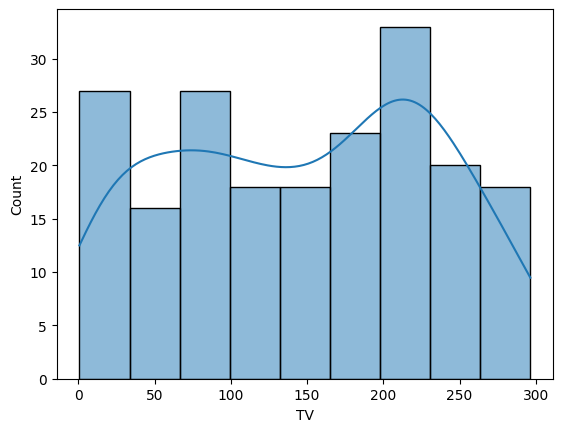

In [5]:
sns.histplot(df['TV'],kde = True)


<Axes: xlabel='TV'>

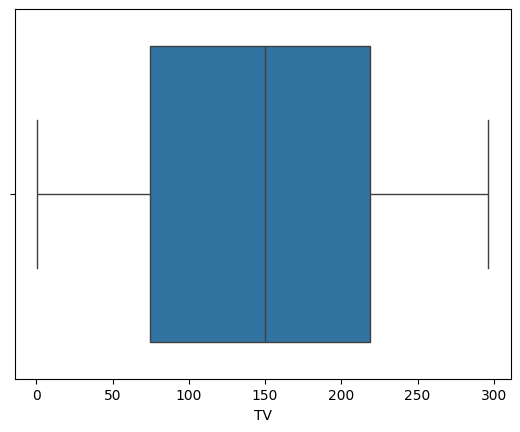

In [6]:
sns.boxplot(x='TV',data=df)

In [7]:
df['TV'].describe()

count    200.000000
mean     147.042500
std       85.854236
min        0.700000
25%       74.375000
50%      149.750000
75%      218.825000
max      296.400000
Name: TV, dtype: float64

<Axes: xlabel='Sales', ylabel='Count'>

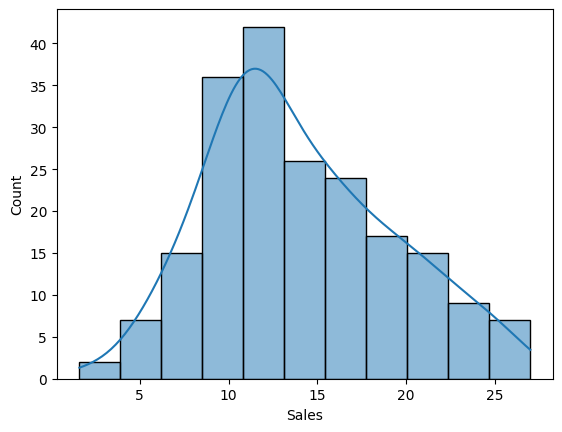

In [8]:
sns.histplot(df['Sales'],kde = True)

In [9]:
df['Sales'].describe()

count    200.000000
mean      14.022500
std        5.217457
min        1.600000
25%       10.375000
50%       12.900000
75%       17.400000
max       27.000000
Name: Sales, dtype: float64

<Axes: xlabel='Sales'>

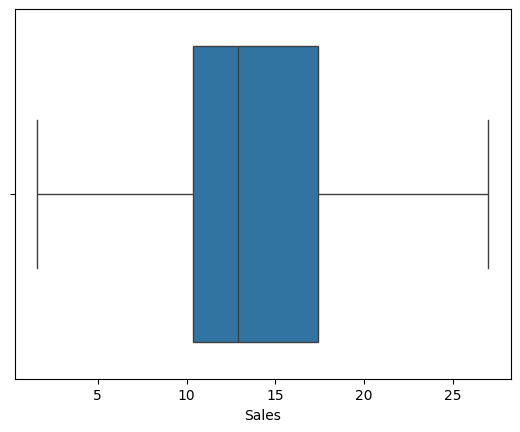

In [10]:
sns.boxplot(x='Sales',data=df)

In [11]:
scaler = StandardScaler()
standerdized = scaler.fit_transform(df)
df_scaled = pd.DataFrame(standerdized,columns=df.columns)


In [12]:
df_scaled.head()

,TV,Sales
0,0.969852,1.552053
1,-1.197376,-0.696046
2,-1.516155,-0.907406
3,0.052050,0.860330
4,0.394182,-0.215683


<Axes: xlabel='Sales', ylabel='Count'>

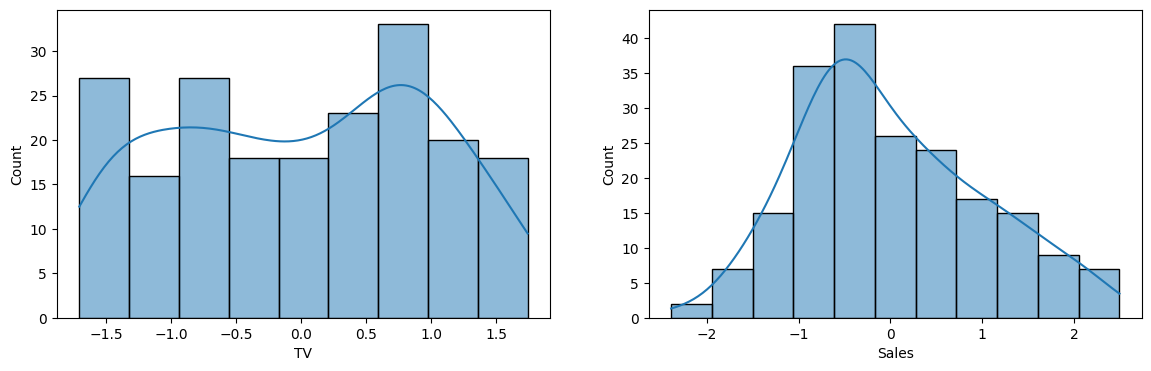

In [13]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.histplot(df_scaled['TV'],kde=True)

plt.subplot(1,2,2)
sns.histplot(df_scaled['Sales'],kde=True)

<Axes: xlabel='Sales'>

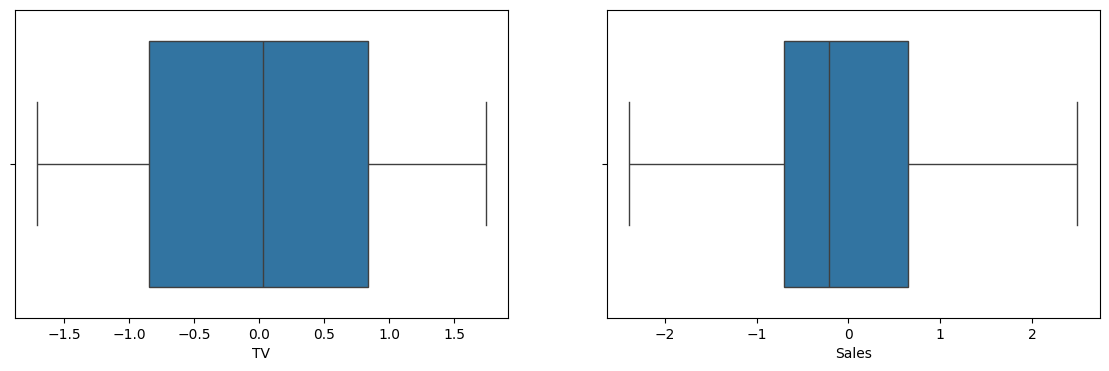

In [14]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.boxplot(x='TV',data=df_scaled)

plt.subplot(1,2,2)
sns.boxplot(x='Sales',data=df_scaled)

In [15]:
x= df_scaled.drop(['Sales'],axis=1)
y= df_scaled['Sales']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,train_size=0.8,random_state=42)

In [16]:
lin= LinearRegression()
lin.fit(x_train,y_train)
y_pred = lin.predict(x_test)

In [17]:
mse=cross_val_score(lin,x_train,y_train,scoring='r2',cv=5)
np.mean(mse)

0.5379788597613626

In [18]:
print("Intercept:", lin.intercept_)
print("Coefficients:", lin.coef_)

Intercept: -0.01172339580582341
Coefficients: [0.76565558]


In [19]:
pt= PowerTransformer(method='yeo-johnson')

In [20]:
x_train_trans = pt.fit_transform(x_train)
x_test_trans= pt.transform(x_test)


In [21]:
# 1. Initialize a new Linear Regression model
lin_transformed = LinearRegression()

# 2. Train it on the power-transformed training data
lin_transformed.fit(x_train_trans, y_train)

# 3. Make predictions on the transformed test data
y_pred_trans = lin_transformed.predict(x_test_trans)

In [22]:
# --- 1. Evaluate the Original Model (with corrected variable names) ---

# Calculate R2 and MSE on the test set for the first model
r2_original = r2_score(y_test, y_pred)
mse_original = mean_squared_error(y_test, y_pred)


# --- 2. Train and Evaluate a New Model on Transformed Data ---

# Initialize a new Linear Regression model
lin_transformed = LinearRegression()

# Train it on the power-transformed training data
lin_transformed.fit(x_train_trans, y_train)

# Make predictions using the transformed test data
y_pred_trans = lin_transformed.predict(x_test_trans)

# Calculate R2 and MSE for the new model
r2_trans = r2_score(y_test, y_pred_trans)
mse_trans = mean_squared_error(y_test, y_pred_trans)


# --- 3. Compare the Results ---

print("--- Original Model (Standard Scaled Only) ---")
print(f"R2 Score: {r2_original:.4f}")
print(f"Mean Squared Error: {mse_original:.4f}")

print("\n--- New Model (Standard Scaled + Yeo-Johnson Transformed) ---")
print(f"R2 Score: {r2_trans:.4f}")

print(f"Mean Squared Error: {mse_trans:.4f}")

--- Original Model (Standard Scaled Only) ---
R2 Score: 0.6767
Mean Squared Error: 0.3768

--- New Model (Standard Scaled + Yeo-Johnson Transformed) ---
R2 Score: 0.6734
Mean Squared Error: 0.3806


In [23]:
print("Skewness before:", x_train['TV'].skew())
print("Skewness after:", pd.Series(x_train_trans[:,0]).skew())


Skewness before: -0.09403415395825016
Skewness after: -0.018956977117459008


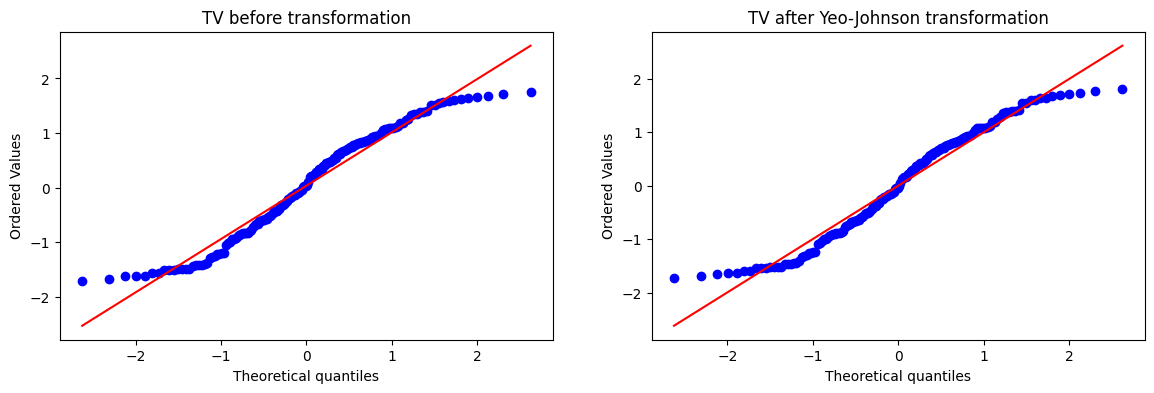

In [24]:
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
stats.probplot(x_train['TV'], dist='norm', plot=plt)
plt.title('TV before transformation')

plt.subplot(1,2,2)
stats.probplot(x_train_trans[:, 0], dist='norm', plot=plt)
plt.title('TV after Yeo-Johnson transformation')
plt.show()


# Polynomial regression

In [25]:
df = pd.read_csv('tvmarketing.csv')


In [26]:
x= df.drop(['Sales'],axis=1)
y= df['Sales']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [27]:
poly = PolynomialFeatures(degree=2)  

x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

In [28]:
lin = LinearRegression()
lin.fit(x_train_poly, y_train)

LinearRegression()

In [29]:
y_pred = lin.predict(x_test_poly)


In [30]:
mse= cross_val_score(poly,x_train_poly,y_train,scoring='neg_mean_squared_error',cv=5)
mse=-(np.mean(mse))
print(mse)

nan


d:\Programing\Machine learning\venv_py311\Lib\site-packages\sklearn\model_selection\_validation.py:1011: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "d:\Programing\Machine learning\venv_py311\Lib\site-packages\sklearn\metrics\_scorer.py", line 137, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "d:\Programing\Machine learning\venv_py311\Lib\site-packages\sklearn\metrics\_scorer.py", line 344, in _score
    response_method = _check_response_method(estimator, self._response_method)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Programing\Machine learning\venv_py311\Lib\site-packages\sklearn\utils\validation.py", line 2106, in _check_response_method
    raise AttributeError(
AttributeError: PolynomialFeatures has none of the following attributes: predict.

  warnings.warn(
d:\Programing\Machine learning\v

d:\Programing\Machine learning\venv_py311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


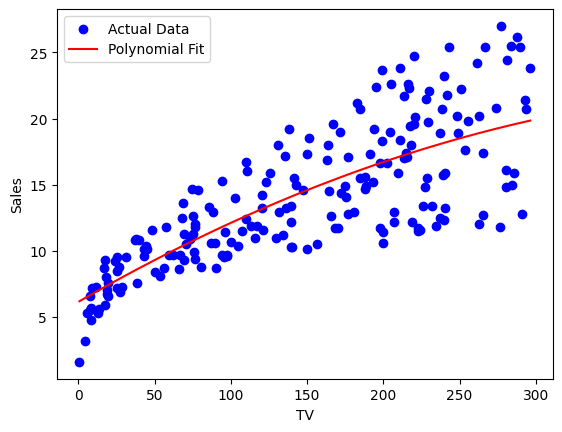

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Sort the values for a smooth curve
x_sorted = np.sort(x.values, axis=0)
x_sorted_poly = poly.transform(x_sorted)
y_sorted_pred = lin.predict(x_sorted_poly)

plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(x_sorted, y_sorted_pred, color='red', label='Polynomial Fit')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.legend()
plt.show()


In [32]:
# --- 1. Re-evaluate Simple Linear Regression on UN SCALED data ---
# (Using the unscaled x_train, x_test, y_train, y_test you created for the polynomial model)
lin_simple = LinearRegression()
lin_simple.fit(x_train, y_train)
y_pred_simple = lin_simple.predict(x_test)
r2_simple = r2_score(y_test, y_pred_simple)
mse_simple = mean_squared_error(y_test, y_pred_simple)


# --- 2. Evaluate the Polynomial Regression model on the TEST set ---
# (Using the polynomial model `lin` and predictions `y_pred` you already created)
r2_poly = r2_score(y_test, y_pred)
mse_poly = mean_squared_error(y_test, y_pred)


# --- 3. Compare the Results ---
print("--- Simple Linear Regression (Unscaled Data) ---")
print(f"Test R2 Score: {r2_simple:.4f}")
print(f"Test Mean Squared Error: {mse_simple:.4f}")

print("\n--- Polynomial Regression (Degree 2) ---")
print(f"Test R2 Score: {r2_poly:.4f}")
print(f"Test Mean Squared Error: {mse_poly:.4f}")
print(f"(Cross-Validated Training MSE from your last step: {mse:.4f})")

--- Simple Linear Regression (Unscaled Data) ---
Test R2 Score: 0.6767
Test Mean Squared Error: 10.2047

--- Polynomial Regression (Degree 2) ---
Test R2 Score: 0.6825
Test Mean Squared Error: 10.0201
(Cross-Validated Training MSE from your last step: nan)


# Lasso regression 

In [33]:
df=pd.read_csv('tvmarketing.csv')
df.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [34]:
x= df_scaled.drop(['Sales'],axis=1)
y= df_scaled['Sales']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,train_size=0.8,random_state=42)

In [35]:
# This step was unnecessary
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [36]:
lasso_cv = LassoCV(cv=5, random_state=42) # cv=3 means 3-fold cross-validation
lasso_cv.fit(X_train_scaled, y_train)

best_alpha = lasso_cv.alpha_
print(f"Best Alpha found: {best_alpha:.4f}")

Best Alpha found: 0.0008


In [37]:
from sklearn.linear_model import Lasso

# 5. Train the final model with the best alpha
lasso_model = Lasso(alpha=best_alpha)
lasso_model.fit(X_train_scaled, y_train)

Lasso(alpha=0.0007523816939166897)

In [38]:
from sklearn.metrics import r2_score, mean_squared_error

# 6. Make predictions and evaluate
y_pred = lasso_model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Test R2 Score: {r2:.4f}")
print(f"Test Mean Squared Error: {mse:.4f}")

Test R2 Score: 0.6766
Test Mean Squared Error: 0.3769


In [39]:
# 7. View the results
coefficients = pd.Series(lasso_model.coef_, index=x.columns)
print("\nModel Coefficients:")
print(coefficients)


Model Coefficients:
TV    0.751629
dtype: float64


# evalMl

In [52]:
import evalml
evalml.problem_types.ProblemTypes.all_problem_types

[<ProblemTypes.BINARY: 'binary'>,
 <ProblemTypes.MULTICLASS: 'multiclass'>,
 <ProblemTypes.REGRESSION: 'regression'>,
 <ProblemTypes.TIME_SERIES_REGRESSION: 'time series regression'>,
 <ProblemTypes.TIME_SERIES_BINARY: 'time series binary'>,
 <ProblemTypes.TIME_SERIES_MULTICLASS: 'time series multiclass'>,
 <ProblemTypes.MULTISERIES_TIME_SERIES_REGRESSION: 'multiseries time series regression'>]

In [48]:

df= pd.read_csv('tvmarketing.csv')
y=df['Sales']
X=df.drop(columns=['Sales'])


In [61]:
X_train, X_test, y_train, y_test = evalml.preprocessing.split_data(X, y, problem_type='regression')

In [62]:
automl = evalml.AutoMLSearch(
    X_train=X_train,
    y_train=y_train,
    problem_type='regression'  # Ise 'binary' kar dena agar classification hai
)

automl.search()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000015 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 37
[LightGBM] [Info] Number of data points in the train set: 106, number of used features: 1
[LightGBM] [Info] Start training from score 13.893396
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

{1: {'Random Forest Regressor w/ Imputer + RF Regressor Select From Model': 1.402406930923462,
  'Total time of batch': 1.7576074600219727},
 2: {'Extra Trees Regressor w/ Imputer + Select Columns Transformer': 0.5233297348022461,
  'XGBoost Regressor w/ Imputer + Select Columns Transformer': 0.1895768642425537,
  'LightGBM Regressor w/ Imputer + Select Columns Transformer': 0.10184240341186523,
  'Elastic Net Regressor w/ Imputer + Standard Scaler + Select Columns Transformer': 0.10971736907958984,
  'Total time of batch': 2.773463010787964}}

In [63]:
automl.rankings


,id,pipeline_name,search_order,ranking_score,mean_cv_score,standard_deviation_cv_score,percent_better_than_baseline,high_variance_cv,parameters
0,5,Elastic Net Regressor w/ Imputer + Standard Sc...,5,0.574610,0.574610,0.028594,3100.063732,False,{'Imputer': {'categorical_impute_strategy': 'm...
1,4,LightGBM Regressor w/ Imputer + Select Columns...,4,0.519667,0.519667,0.029123,2813.203158,False,{'Imputer': {'categorical_impute_strategy': 'm...
2,2,Extra Trees Regressor w/ Imputer + Select Colu...,2,0.481245,0.481245,0.006226,2612.600308,False,{'Imputer': {'categorical_impute_strategy': 'm...
3,1,Random Forest Regressor w/ Imputer + RF Regres...,1,0.417153,0.417153,0.035088,2277.971063,False,{'Imputer': {'categorical_impute_strategy': 'm...
4,3,XGBoost Regressor w/ Imputer + Select Columns ...,3,0.261511,0.261511,0.118112,1465.362063,False,{'Imputer': {'categorical_impute_strategy': 'm...
5,0,Mean Baseline Regression Pipeline,0,-0.019153,-0.019153,0.015609,0.000000,False,{'Baseline Regressor': {'strategy': 'mean'}}


In [43]:
import evalml
from evalml import AutoMLSearch

In [54]:
automl.best_pipeline

pipeline = RegressionPipeline(component_graph={'Imputer': ['Imputer', 'X', 'y'], 'Standard Scaler': ['Standard Scaler', 'Imputer.x', 'y'], 'Select Columns Transformer': ['Select Columns Transformer', 'Standard Scaler.x', 'y'], 'Elastic Net Regressor': ['Elastic Net Regressor', 'Select Columns Transformer.x', 'y']}, parameters={'Imputer':{'categorical_impute_strategy': 'most_frequent', 'numeric_impute_strategy': 'mean', 'boolean_impute_strategy': 'most_frequent', 'categorical_fill_value': None, 'numeric_fill_value': None, 'boolean_fill_value': None}, 'Select Columns Transformer':{'columns': ['TV']}, 'Elastic Net Regressor':{'alpha': 0.0001, 'l1_ratio': 0.15, 'max_iter': 1000}}, random_seed=0)

In [55]:
best_pipeline=automl.best_pipeline

Lets checkthe detailed description

In [64]:
automl.describe_pipeline(automl.rankings.iloc[0]["id"])


***********************************************************************************
* Elastic Net Regressor w/ Imputer + Standard Scaler + Select Columns Transformer *
***********************************************************************************

Problem Type: regression
Model Family: Linear

Pipeline Steps
1. Imputer
	 * categorical_impute_strategy : most_frequent
	 * numeric_impute_strategy : mean
	 * boolean_impute_strategy : most_frequent
	 * categorical_fill_value : None
	 * numeric_fill_value : None
	 * boolean_fill_value : None
2. Standard Scaler
3. Select Columns Transformer
	 * columns : ['TV']
4. Elastic Net Regressor
	 * alpha : 0.0001
	 * l1_ratio : 0.15
	 * max_iter : 1000

Training
Training for regression problems.
Total training time (including CV): 0.1 seconds

Cross Validation
----------------
               R2  ExpVariance  MaxError  MedianAE    MSE   MAE  Root Mean Squared Error # Training # Validation
0           0.581        0.589     7.742     2.463 13.173 

In [75]:
best_pipeline.score(X_test,y_test,objectives=["r2", "root mean squared error", "mae", "mse"])

OrderedDict([('R2', 0.6763004313650618),
             ('Root Mean Squared Error', 3.19165245085621),
             ('MAE', 2.5054733127517617),
             ('MSE', 10.186645367056451)])

In [67]:
evalml.objectives.get_all_objective_names()

['expvariance',
 'maxerror',
 'medianae',
 'mse',
 'mae',
 'r2',
 'mean squared log error',
 'root mean squared log error',
 'root mean squared error',
 'symmetric mean absolute percentage error',
 'mean absolute percentage error',
 'mean absolute scaled error',
 'mcc multiclass',
 'log loss multiclass',
 'auc weighted',
 'auc macro',
 'auc micro',
 'recall weighted',
 'recall macro',
 'recall micro',
 'precision weighted',
 'precision macro',
 'precision micro',
 'f1 weighted',
 'f1 macro',
 'f1 micro',
 'balanced accuracy multiclass',
 'accuracy multiclass',
 'mcc binary',
 'log loss binary',
 'gini',
 'auc',
 'recall',
 'precision',
 'f1',
 'balanced accuracy binary',
 'accuracy binary',
 'sensitivity at low alert rates',
 'lead scoring',
 'fraud cost',
 'cost benefit matrix']